In [4]:
from jax import config
config.update("jax_enable_x64", True)
from pathlib import Path
import glob 

In [5]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"                      # if multi-GPU
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"         # no huge prealloc
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"        # CUDA allocator
# os.environ["XLA_FLAGS"] = "--xla_gpu_enable_command_buffer=false"  # avoid CUDA graphs


In [6]:
import matplotlib.pyplot as plt 
from spectres import spectres
import numpy as np
import jax.numpy as jnp 
import pickle 
import pandas as pd 

In [7]:
from sheap import Sheapectral 
from sheap.Utils.SpectralReaders import parallel_reader 
#from sheap.Utils.Constants import SINGLE_EPOCH_ESTIMATORS

In [8]:
%load_ext autoreload
%autoreload 2

In [10]:
name_files = "paula_binB"
with open(f"../pickle_spectra/{name_files}.pkl", "rb") as f:
    dict_spectra = pickle.load(f)
base_panda = pd.read_csv(f"../pickle_spectra/{name_files}.csv")

In [11]:
# base_panda[['logBHmass_Hbeta', 'logBHmass_Hbeta_err']]

In [12]:
names = list(dict_spectra.keys())
spectra = np.stack([i["new"] for i in dict_spectra.values()])
z = np.stack([i["z"] for i in dict_spectra.values()])
coords = np.stack([i["coords"] for i in dict_spectra.values()])

In [13]:
sheapspectral = Sheapectral(spectra,z=z,coords=coords,names=names)

extinction correction will be do it, change 'extinction_correction' to done if you want to avoid this step
redshift correction will be do it, change 'redshift_correction' to done if you want to avoid this step


In [16]:
sheapspectral.spectra.shape

(151, 3, 3808)

<Axes: xlabel='Wavelength [Å]', ylabel='Flux [arb]'>

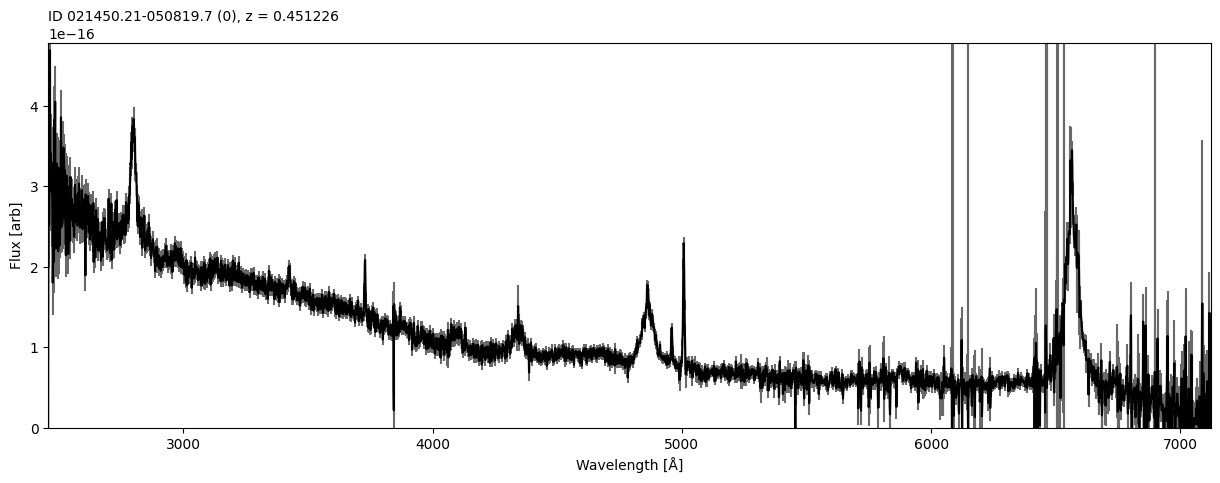

In [17]:
sheapspectral.quicklook(0)

array([<Axes: xlabel='Redshift (z)', ylabel='Number of objects'>,
       <Axes: xlabel='Mean Signal-to-Noise Ratio'>], dtype=object)

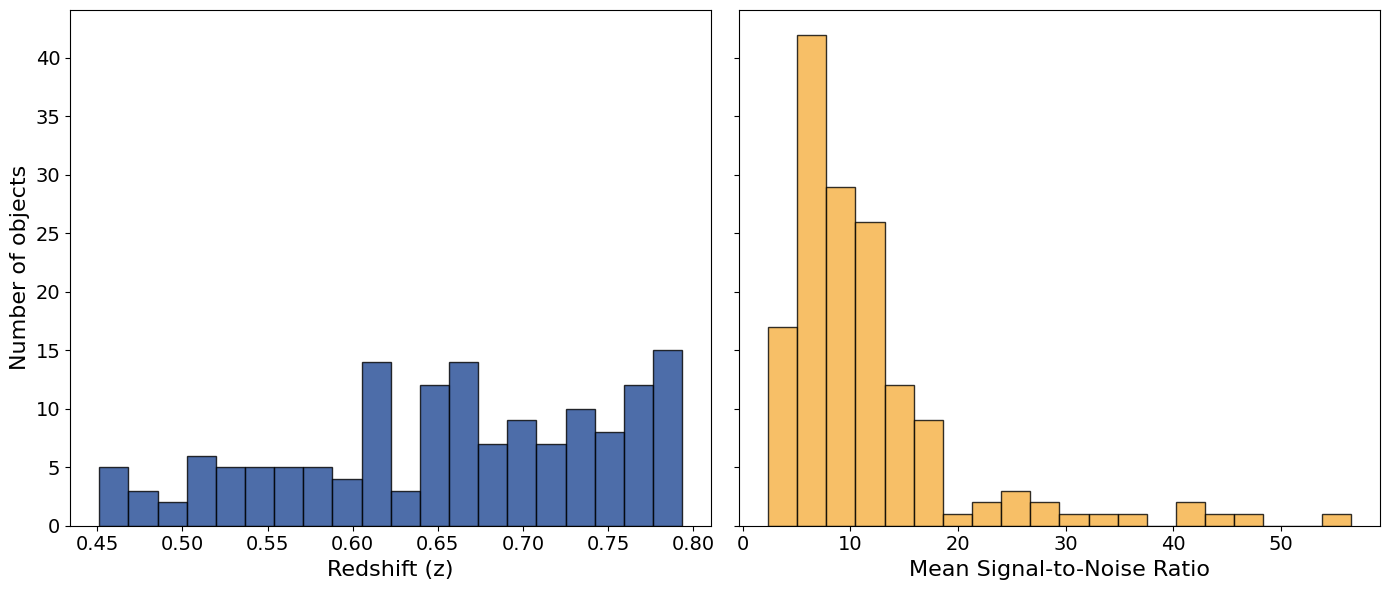

In [18]:
sheapspectral.plot_redshift_signal2noise_distribution

In [19]:
add_host_miles = {"z_include":None,"age_include":None}
#z_include: Optional[Union[tuple[float, float], list[float]]] = [-0.7, 0.22],
#age_include: Optional[Union[tuple[float, float], list[float]]] = [0.1, 10.0],
sheapspectral.makemodel(limits=(2450, 5500),n_broad=2,n_narrow=1,group_method=True,fe_mode ="template",continuum_profile="powerlaw",add_winds=False,
                           add_outflow=True,
                           add_uncommon_narrow=False,
                           add_host_miles = add_host_miles,
                           )

sheapspectral.fitmodel(list_num_steps=[2_000],list_learning_rate=[1e-2],run_fit=True,add_penalty_function=False,
                         penalty_weight = 0.0,curvature_weight=0.0,smoothness_weight=0.0,max_weight=0.0)

Fitting 151 spectra with 3808 wavelength pixels

STEP1 (step1) params to minimize 421
learning_rate: 0.01 num_steps: 2000 non_optimize_in_axis: 4
Time for step 'step1': 53.46 seconds
The entire process took 53.46 (0.35s by spectra)


NaN / non-finite entries at indices: []
Number of NaNs / non-finite values: 0


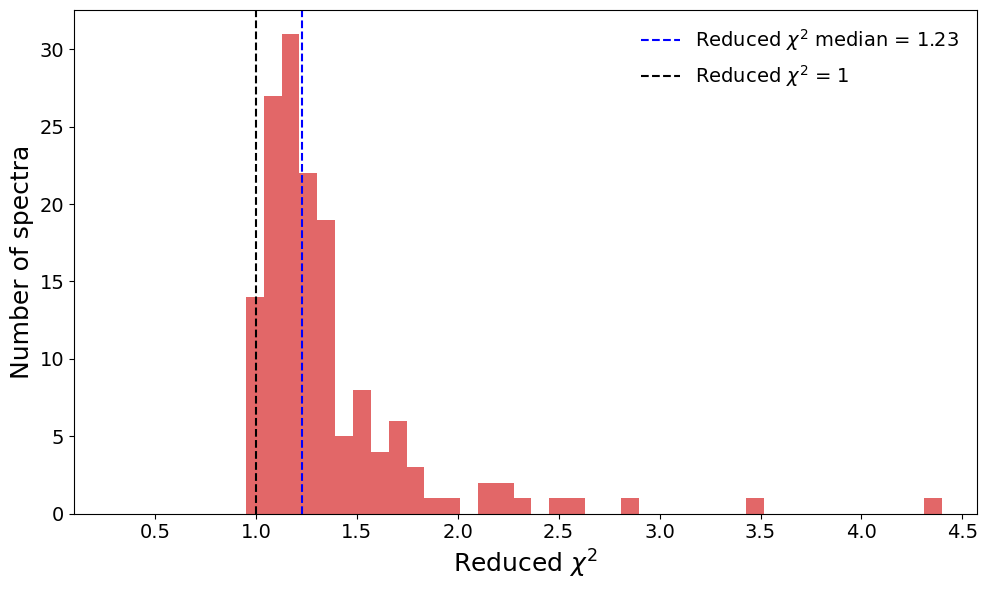

In [20]:
sheapspectral.plot_chi2

In [ ]:
sheapspectral.estimate_posteriors(sampling_method="montecarlo",overwrite=True,summarize=False,num_samples= 50)
sheapspectral.save_to_pickle("SS18B_montecarlo_rachi.pkl")

Running Monte Carlo with JAX.,sample over the spectra using init params


Getting posterior-params:   1%|          | 1/151 [00:14<35:02, 14.02s/it]

TODO implement Le20_MgII_3000_FWHM
TODO implement Pan25_MgII_3000_RFe
TODO implement Le20_MgII_3000_FWHM
TODO implement Pan25_MgII_3000_RFe


Getting posterior-params:   1%|▏         | 2/151 [00:14<14:57,  6.03s/it]

TODO implement Le20_MgII_3000_FWHM
TODO implement Pan25_MgII_3000_RFe
TODO implement Le20_MgII_3000_FWHM
TODO implement Pan25_MgII_3000_RFe


...

TODO implement Le20_MgII_3000_FWHM
TODO implement Pan25_MgII_3000_RFe
TODO implement Le20_MgII_3000_FWHM
TODO implement Pan25_MgII_3000_RFe


Getting posterior-params: 100%|██████████| 151/151 [01:20<00:00,  1.88it/s]

TODO implement Le20_MgII_3000_FWHM
TODO implement Pan25_MgII_3000_RFe
TODO implement Le20_MgII_3000_FWHM
TODO implement Pan25_MgII_3000_RFe


Estimated pickle size: 61469.86 KB


: 

NaN / non-finite entries at indices: []
Number of NaNs / non-finite values: 0


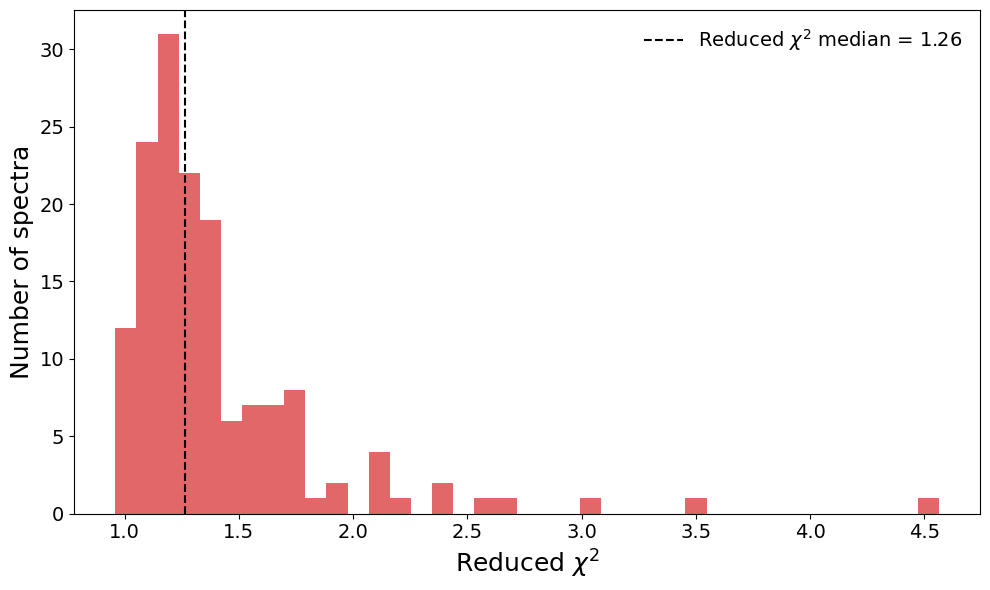

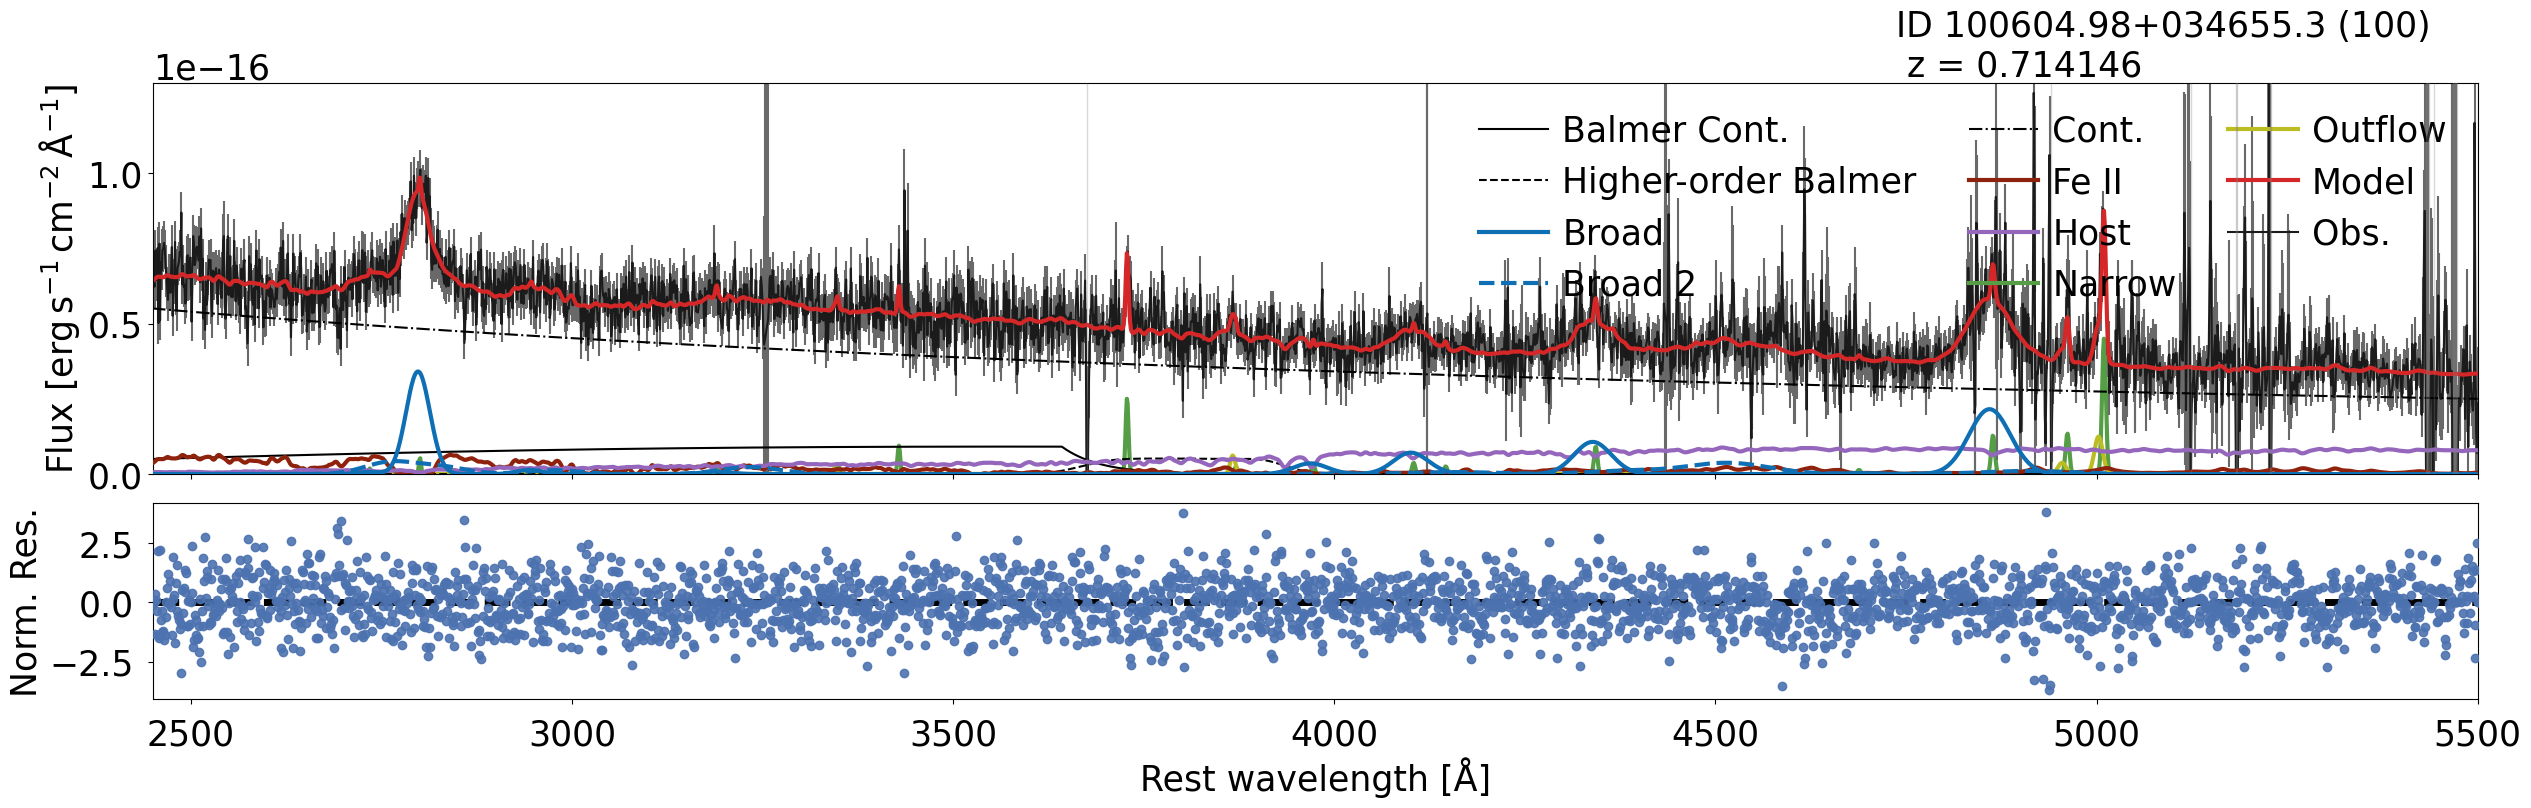

In [36]:
sheapspectral.modelplot.plot(100,add_legend=True,add_lines_name=False)

Running Monte Carlo with JAX.,sample over the spectra


Getting posterior-params: 100%|██████████| 151/151 [02:51<00:00,  1.13s/it]


Estimated pickle size: 72722.22 KB


: 

In [13]:
pd.set_option('display.max_rows', None)
sheapspectral.result_panda(21)

,value,error,max_constraint,init_valeu,min_constraint,param_number
amplitude_balmercontinuum_0_balmer,0.26558107,0.0,10.0,0.010000,0.0,0
T_raw_balmercontinuum_0_balmer,2.328751,0.0,20.0,9.000000,-10.0,1
tau_raw_balmercontinuum_0_balmer,6.713041,0.0,20.0,-1.000000,-10.0,2
v_raw_balmercontinuum_0_balmer,0.128173,0.0,5.0,0.000000,-5.0,3
logamp_balmerhighorder_0_balmer,0.883974,0.0,10.0,1.000000,-2.0,4
logFWHM_balmerhighorder_0_balmer,3.461733,0.0,3.903090000152588,3.301030,2.903090000152588,5
shift_balmerhighorder_0_balmer,7.943624,0.0,18.387720108032227,0.000000,-18.387720108032227,6
amplitude0_broad1_1_broad,0.004018527,0.0,10.0,0.010000,0.0,7
amplitude1_broad1_1_broad,2.1005387,0.0,10.0,0.010000,0.0,8
amplitude2_broad1_1_broad,0.00010767556,0.0,10.0,0.010000,0.0,9


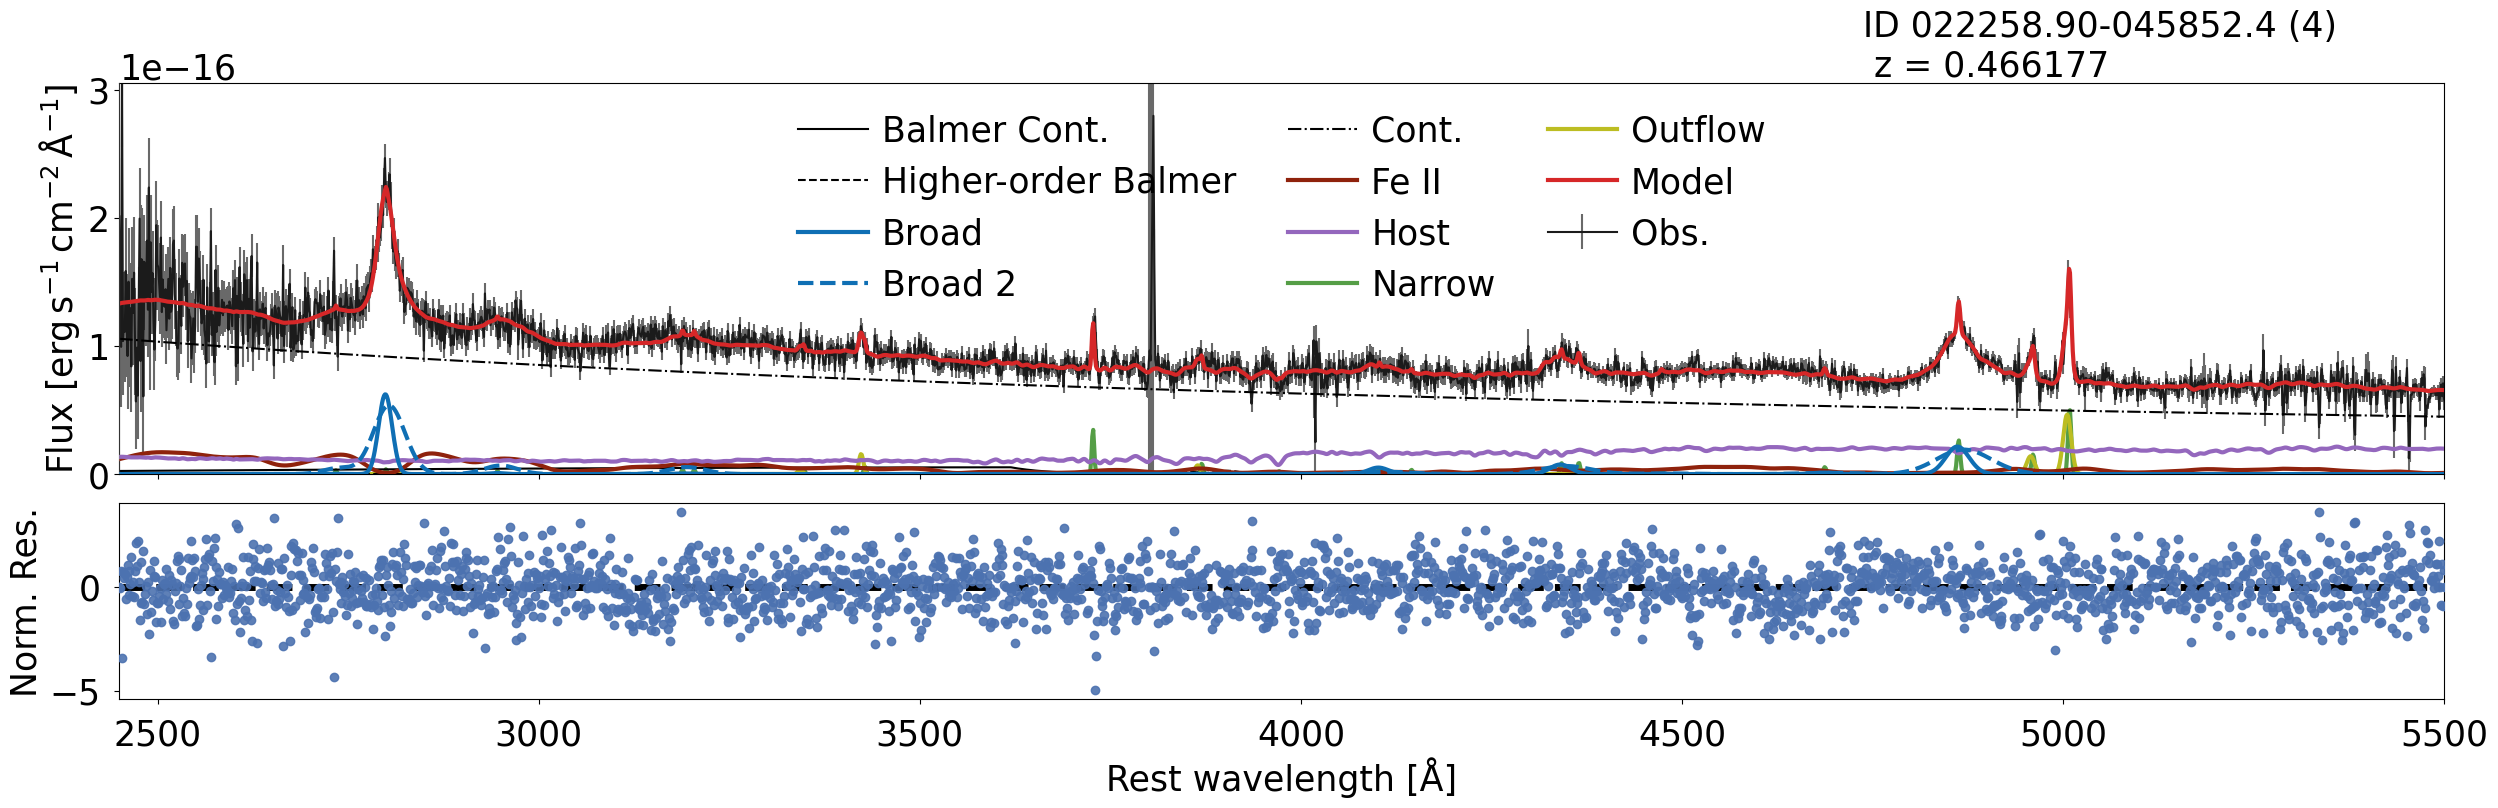

In [31]:
sheapspectral.modelplot.plot(4)

array([<Axes: xlabel='Redshift (z)', ylabel='Number of objects'>,
       <Axes: xlabel='Mean Signal-to-Noise Ratio'>], dtype=object)

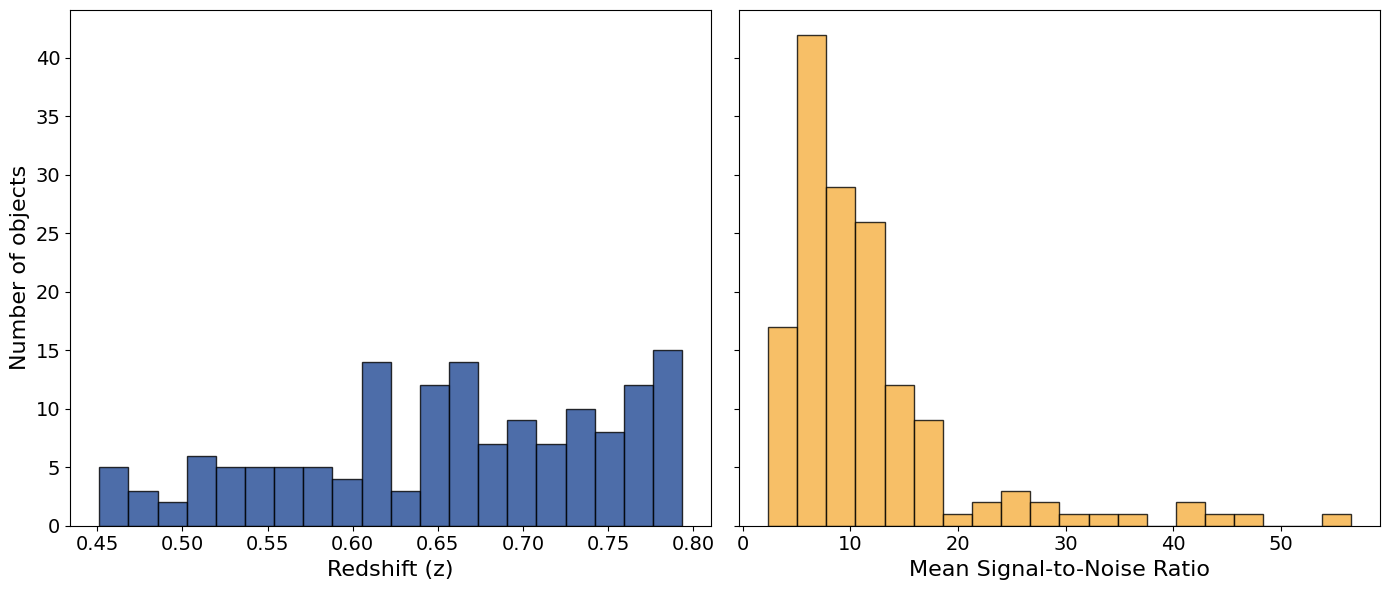

In [37]:
sheapspectral.plot_redshift_signal2noise_distribution

NaN / non-finite entries at indices: []
Number of NaNs / non-finite values: 0


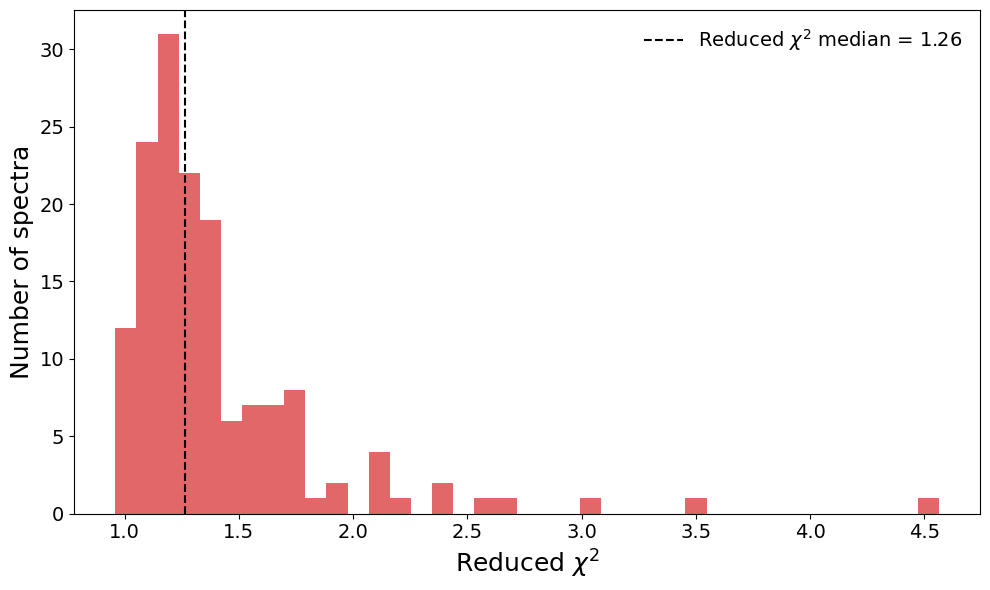

In [38]:
sheapspectral.plot_chi2

In [19]:
sheapspectral.estimate_posteriors(sampling_method="montecarlo",overwrite=True,summarize=False,num_samples= 50)

Running Monte Carlo with JAX.,sample over the spectra


Getting posterior-params: 100%|██████████| 151/151 [02:55<00:00,  1.16s/it]


In [ ]:
sheapspectral.save_to_pickle("SS18B.pkl")

Estimated pickle size: 72008.58 KB


: 

In [ ]:
jj =sheapspectral.from_pickle("montecarlo_sanchez.pkl")